In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('reduced-data3.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Imports

In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
from sklearn.metrics import accuracy_score


ModuleNotFoundError: No module named 'tensorflow.python'

# Loading our data and exploratory data analysis (EDA)

In [6]:
import pandas as pd

# Load the data
data = pd.read_csv('reduced_data3.csv')

# Convert 'date' column to datetime
data['date'] = pd.to_datetime(data['date'], format='%m/%d/%Y %H:%M')

# Check for missing values
missing_values = data.isnull().sum()

# Basic statistics and info
data_info = data.describe()
data_info = data.info()

# Exploratory Data Analysis
# Volume of emails sent over time
email_volume = data.groupby(data['date'].dt.date).size()

# Frequency of emails by user
user_frequency = data['user'].value_counts()

# Number of attachments analysis
attachment_analysis = data['attachments'].value_counts()

# Display results
print("Missing Values:\n", missing_values)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0                   2000 non-null   object        
 1   date            2000 non-null   datetime64[ns]
 2   user            2000 non-null   object        
 3   pc              2000 non-null   object        
 4   to              2000 non-null   object        
 5   cc              740 non-null    object        
 6   bcc             327 non-null    object        
 7   from            2000 non-null   object        
 8   size            2000 non-null   int64         
 9   attachments     2000 non-null   int64         
 10  content         2000 non-null   object        
 11  day_of_week     2000 non-null   int64         
 12  email_count     2000 non-null   int64         
 13  insider_threat  2000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(8)
memory usage: 

In [7]:
print("Data Info:\n", data_info)

Data Info:
 None


In [8]:
print("Email Volume Over Time:\n", email_volume)

Email Volume Over Time:
 date
2010-01-02     2
2010-01-03     2
2010-01-04    28
2010-01-05    29
2010-01-06    30
              ..
2010-04-14    24
2010-04-15    27
2010-04-16    19
2010-04-18     2
2010-04-19    24
Length: 101, dtype: int64


In [9]:
print("User Frequency:\n", user_frequency)

User Frequency:
 user
AJR0319    12
HCS0003    10
RZC0746    10
QRM0739    10
HTH0007    10
           ..
KNW0644     1
LDB0090     1
FHO0630     1
CLD0894     1
RFP0380     1
Name: count, Length: 720, dtype: int64


In [10]:
print("Attachment Analysis:\n", attachment_analysis)

Attachment Analysis:
 attachments
0    1547
1     270
2      88
3      36
4      27
6      13
5      10
8       5
7       3
9       1
Name: count, dtype: int64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'date' column to datetime
data['date'] = pd.to_datetime(data['date'], format='%m/%d/%Y %H:%M:%S')

# Handle missing values in 'cc' and 'bcc'
data['cc'] = data['cc'].fillna('')
data['bcc'] = data['bcc'].fillna('')

# Feature Engineering
data['num_recipients'] = data['to'].str.count(';') + data['cc'].str.count(';') + data['bcc'].str.count(';') + 1
data['hour'] = data['date'].dt.hour
data['day_of_week'] = data['date'].dt.dayofweek


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


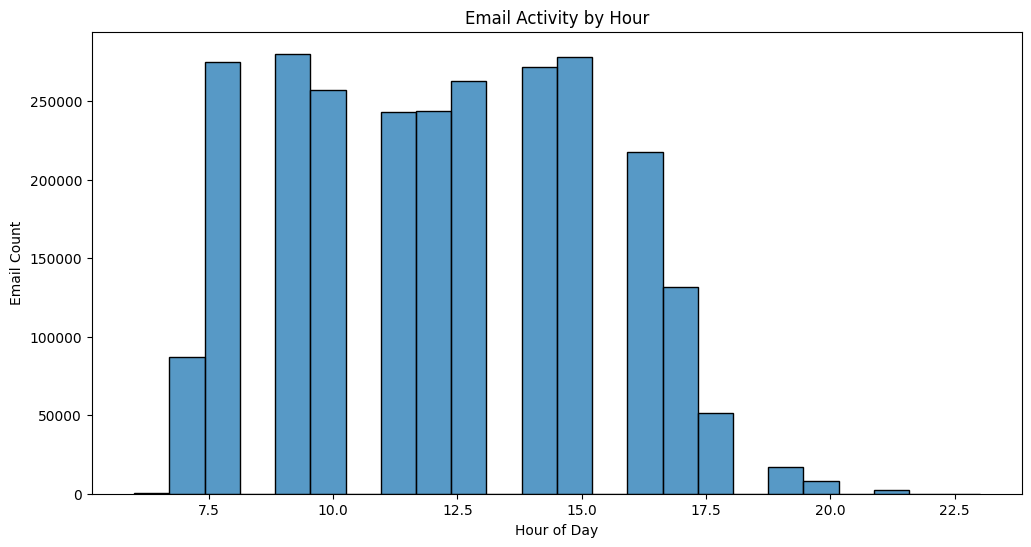

In [9]:
# Time-based Analysis
plt.figure(figsize=(12, 6))
sns.histplot(data['hour'], bins=24, kde=False)
plt.title('Email Activity by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Email Count')
plt.show()

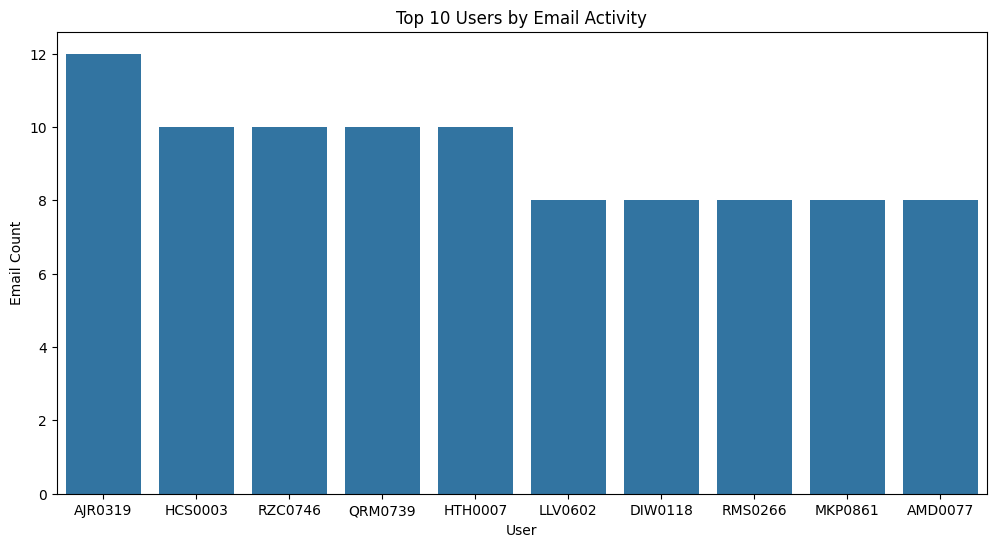

In [12]:
# User-based Analysis
top_users = data['user'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_users.index, y=top_users.values)
plt.title('Top 10 Users by Email Activity')
plt.xlabel('User')
plt.ylabel('Email Count')
plt.show()

In [13]:
# Prepare data for anomaly detection
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

features = ['size', 'attachments', 'num_recipients', 'hour', 'day_of_week']
X = data[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the model
model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
data['anomaly'] = model.fit_predict(X_scaled)

# Analyze anomalies
anomalies = data[data['anomaly'] == -1]

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


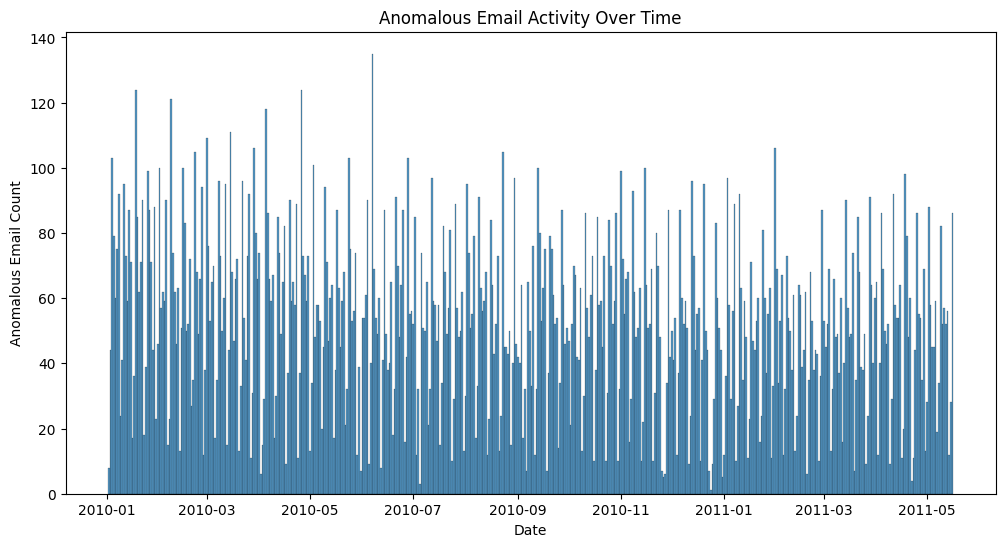

Number of Anomalies Detected: 26300


In [12]:
# Plot anomalies over time
plt.figure(figsize=(12, 6))
sns.histplot(anomalies['date'].dt.date, bins=30, kde=False)
plt.title('Anomalous Email Activity Over Time')
plt.xlabel('Date')
plt.ylabel('Anomalous Email Count')
plt.show()

print(f"Number of Anomalies Detected: {len(anomalies)}")

# Data preprocessing

In [14]:
# Sample 10% of your data
data_sample = data.sample(frac=0.1, random_state=42)

In [15]:
# Continue with your preprocessing
data_sample['date'] = pd.to_datetime(data_sample['date'], format='%m/%d/%Y %H:%M:%S')
data_sample['cc'] = data_sample['cc'].fillna('')
data_sample['bcc'] = data_sample['bcc'].fillna('')

data_sample['num_recipients'] = data_sample['to'].str.count(';') + data_sample['cc'].str.count(';') + data_sample['bcc'].str.count(';') + 1
data_sample['hour'] = data_sample['date'].dt.hour
data_sample['day_of_week'] = data_sample['date'].dt.dayofweek

In [16]:
# Vectorize content using TF-IDF
tfidf = TfidfVectorizer(max_features=1000)
content_tfidf = tfidf.fit_transform(data_sample['content']).toarray()
content_tfidf_df = pd.DataFrame(content_tfidf, columns=tfidf.get_feature_names_out())

In [17]:
# Combine numeric features with TF-IDF features
features = ['size', 'attachments', 'num_recipients', 'hour', 'day_of_week']
X_numeric = data_sample[features]
X = pd.concat([X_numeric.reset_index(drop=True), content_tfidf_df.reset_index(drop=True)], axis=1)


In [18]:
# Standardize numeric features
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)
X_scaled = pd.concat([pd.DataFrame(X_numeric_scaled, columns=features).reset_index(drop=True), content_tfidf_df.reset_index(drop=True)], axis=1)

In [19]:
# Use IsolationForest to detect anomalies and create the 'anomaly' column
model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
data_sample['anomaly'] = model.fit_predict(X_scaled)
data_sample['anomaly'] = data_sample['anomaly'].map({1: 0, -1: 1})  # Convert from {1, -1} to {0, 1}

In [20]:
# Split the data
y = data_sample['anomaly']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Random forest

In [21]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [22]:
acc = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy using random forest is: {acc*100:.3f} %")

Accuracy using random forest is: 100.000 %


# LSTM

In [ ]:
from keras.utils import to_categorical

# LSTM
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# LSTM
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

NameError: name 'to_categorical' is not defined

In [23]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=True))
lstm_model.add(LSTM(50))
lstm_model.add(Dense(2, activation='softmax'))

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.fit(X_train_lstm, y_train_cat, epochs=10, batch_size=64, validation_split=0.2, verbose=2)
y_pred_lstm = np.argmax(lstm_model.predict(X_test_lstm), axis=1)
print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm))

/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2630/2630 - 18s - 7ms/step - accuracy: 0.9898 - loss: 0.0625 - val_accuracy: 0.9897 - val_loss: 0.0413
Epoch 2/10
2630/2630 - 13s - 5ms/step - accuracy: 0.9903 - loss: 0.0349 - val_accuracy: 0.9901 - val_loss: 0.0336
Epoch 3/10
2630/2630 - 13s - 5ms/step - accuracy: 0.9908 - loss: 0.0275 - val_accuracy: 0.9908 - val_loss: 0.0284
Epoch 4/10
2630/2630 - 13s - 5ms/step - accuracy: 0.9920 - loss: 0.0224 - val_accuracy: 0.9907 - val_loss: 0.0263
Epoch 5/10
2630/2630 - 14s - 5ms/step - accuracy: 0.9932 - loss: 0.0180 - val_accuracy: 0.9915 - val_loss: 0.0256
Epoch 6/10
2630/2630 - 14s - 5ms/step - accuracy: 0.9943 - loss: 0.0144 - val_accuracy: 0.9914 - val_loss: 0.0284
Epoch 7/10
2630/2630 - 13s - 5ms/step - accuracy: 0.9953 - loss: 0.0119 - val_accuracy: 0.9907 - val_loss: 0.0315
Epoch 8/10
2630/2630 - 14s - 5ms/step - accuracy: 0.9963 - loss: 0.0097 - val_accuracy: 0.9904 - val_loss: 0.0388
Epoch 9/10
2630/2630 - 14s - 5ms/step - accuracy: 0.9971 - loss: 0.0077 - val_accuracy: 

In [24]:
acc = accuracy_score(y_test, y_pred_lstm)
print(f"The Accuracy using LSTM method is : {acc*100:.3f} %")

The Accuracy using LSTM method is : 98.793 %


# GRU

In [25]:
# GRU
X_train_gru = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_gru = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

gru_model = Sequential()
gru_model.add(GRU(50, input_shape=(X_train_gru.shape[1], X_train_gru.shape[2]), return_sequences=True))
gru_model.add(GRU(50))
gru_model.add(Dense(2, activation='softmax'))

gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_model.fit(X_train_gru, y_train_cat, epochs=10, batch_size=64, validation_split=0.2, verbose=2)
y_pred_gru = np.argmax(gru_model.predict(X_test_gru), axis=1)


/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2630/2630 - 16s - 6ms/step - accuracy: 0.9897 - loss: 0.0546 - val_accuracy: 0.9895 - val_loss: 0.0369
Epoch 2/10
2630/2630 - 13s - 5ms/step - accuracy: 0.9904 - loss: 0.0308 - val_accuracy: 0.9901 - val_loss: 0.0304
Epoch 3/10
2630/2630 - 12s - 5ms/step - accuracy: 0.9914 - loss: 0.0247 - val_accuracy: 0.9915 - val_loss: 0.0246
Epoch 4/10
2630/2630 - 13s - 5ms/step - accuracy: 0.9921 - loss: 0.0214 - val_accuracy: 0.9915 - val_loss: 0.0250
Epoch 5/10
2630/2630 - 13s - 5ms/step - accuracy: 0.9928 - loss: 0.0189 - val_accuracy: 0.9922 - val_loss: 0.0243
Epoch 6/10
2630/2630 - 12s - 5ms/step - accuracy: 0.9936 - loss: 0.0163 - val_accuracy: 0.9903 - val_loss: 0.0269
Epoch 7/10
2630/2630 - 12s - 5ms/step - accuracy: 0.9945 - loss: 0.0139 - val_accuracy: 0.9914 - val_loss: 0.0279
Epoch 8/10
2630/2630 - 21s - 8ms/step - accuracy: 0.9953 - loss: 0.0116 - val_accuracy: 0.9915 - val_loss: 0.0313
Epoch 9/10
2630/2630 - 13s - 5ms/step - accuracy: 0.9961 - loss: 0.0098 - val_accuracy: 

In [26]:
print("GRU Classification Report:")
print(classification_report(y_test, y_pred_gru))

GRU Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     52062
           1       0.45      0.33      0.39       538

    accuracy                           0.99     52600
   macro avg       0.72      0.67      0.69     52600
weighted avg       0.99      0.99      0.99     52600



In [27]:
acc = accuracy_score(y_test, y_pred_gru)
print(f"The Accuracy using GRU method is : {acc*100:.3f} %")

The Accuracy using GRU method is : 98.909 %


# Gradient Boosting 

In [28]:
# Gradient Boosting
gbdt = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbdt.fit(X_train, y_train)
y_pred_gbdt = gbdt.predict(X_test)
print("Gradient Boosting Decision Trees Classification Report:")
print(classification_report(y_test, y_pred_gbdt))

Gradient Boosting Decision Trees Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     52062
           1       0.27      0.03      0.05       538

    accuracy                           0.99     52600
   macro avg       0.63      0.51      0.52     52600
weighted avg       0.98      0.99      0.98     52600



In [29]:
acc = accuracy_score(y_test, y_pred_gbdt)
print(f"The Accuracy using Gradient Boosting is: {acc*100:.3f} %")

The Accuracy using Gradient Boosting is: 98.924 %


# Multi-Layer Perceptron (MLP)

In [30]:
# Multi-Layer Perceptron
mlp = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=100, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
print("Multi-Layer Perceptron Classification Report:")
print(classification_report(y_test, y_pred_mlp))

Multi-Layer Perceptron Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     52062
           1       0.53      0.34      0.42       538

    accuracy                           0.99     52600
   macro avg       0.76      0.67      0.71     52600
weighted avg       0.99      0.99      0.99     52600



In [31]:
acc = accuracy_score(y_test, y_pred_mlp)
print(f"The Accuracy using mlp is : {acc*100:.3f} %")

The Accuracy using mlp is : 99.017 %


# Stacking ensemble

In [32]:
# Stacking Ensemble
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gbdt', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=100, random_state=42))
]

stacking = StackingClassifier(estimators=estimators, final_estimator=RandomForestClassifier(n_estimators=100, random_state=42))
stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_test)
print("Stacking Ensemble Classification Report:")
print(classification_report(y_test, y_pred_stacking))

Stacking Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     52062
           1       0.58      0.28      0.38       538

    accuracy                           0.99     52600
   macro avg       0.79      0.64      0.69     52600
weighted avg       0.99      0.99      0.99     52600



In [33]:
acc = accuracy_score(y_test, y_pred_mlp)
print(f"The Accuracy using stacking ensemble method is : {acc*100:.3f} %")

The Accuracy using stacking ensemble method is : 99.017 %
